# AG-HYPOPT · Trial 20

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Nineteen trials are registered; cell 2 reports `phase = trials` (19/5), so proposals carry expected-improvement (ei) values. **Best = trial_08** (objective 0.1099). Picture (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- **trial_08 (0.1099, best):** travel 0.134.
- optimum cluster (0 div): trial_15 0.1103 (0.127), trial_16 0.1112 (0.128), trial_12 0.1115 (0.128), trial_18 0.1121 (0.138), trial_09 0.1126 (0.123), trial_01 0.1127 (0.120), trial_14 0.1127 (0.140), trial_13 0.1132 (0.134), trial_05 = trial_19 0.1135 (0.088 / 0.125).
- lower travel / worse: trial_07 0.1140 (0.097), trial_06 0.1188 (0.082).
- diverging: trial_17 0.1329 (0.088), trial_10 0.1975 (0.099), trial_03 0.1362 (0.074), trial_04 0.1418 (0.074), trial_02 0.1449 (0.264).

State of play: a flat optimum at travel ~0.13 (best nine within ~0.004, objectives 0.1099-0.1135); fourteen divergence-free runs all inhabit it, and the low-travel region (<0.10) is both slightly worse and the source of every sporadic divergence. The residual errors are the same everywhere: mid-T mu overshoot, 3nW high-T mu undershoot, low-T gamma under-recovery. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_20'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (19/5 trials)
ID |     ei | params
 1 | 0.3590 | {"gamma_anneal": 0.47899068912129317, "lr_gamma": 0.5464779341329858, "lr_mu": 0.15612780749933852, "mu_anneal": 0.9862883639667469}
 2 | 3.3344 | {"gamma_anneal": 0.48775402923123146, "lr_gamma": 0.45196073572438666, "lr_mu": 0.09399810630621713, "mu_anneal": 0.8074751283544689}
 3 | 3.8946 | {"gamma_anneal": 0.46714175226060656, "lr_gamma": 0.46201810277461275, "lr_mu": 0.17542763738166486, "mu_anneal": 0.3548365985231538}
 4 | 0.0212 | {"gamma_anneal": 0.4089863034370174, "lr_gamma": 0.40674634040957935, "lr_mu": 0.1359801481031494, "mu_anneal": 0.3785707527768779}
 5 | 1.6783 | {"gamma_anneal": 0.4015106582787971, "lr_gamma": 0.47176548250531125, "lr_mu": 0.14717118369227294, "mu_anneal": 0.3349410647482329}
 6 | 3.7952 | {"gamma_anneal": 0.5402841814891768, "lr_gamma": 0.4152915697227481, "lr_mu": 0.16046624286329603, "mu_anneal": 0.356751644897468}
 7 | 1.8904 | {"gamma_anneal": 0.4634529621869825, "lr_gamma": 0.427

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (19 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 3: **ei 3.89** — `lr_mu=0.175`, `mu_anneal=0.355` (travel **0.144**), `lr_gamma=0.462`, `gamma_anneal=0.467`.
- candidate 6: ei 3.80 — `lr_mu=0.160`, `mu_anneal=0.357` (travel 0.132), `lr_gamma=0.415`, `gamma_anneal=0.540`.
- candidate 2: ei 3.33 — `lr_mu=0.094`, `mu_anneal=0.807` (travel 0.056, low), `lr_gamma=0.452`.
- candidate 8: ei 3.14 — `lr_mu=0.172`, `mu_anneal=0.351` (travel 0.142), `lr_gamma=0.470`, `gamma_anneal=0.838` (high).
- candidate 7: ei 1.89 — `lr_mu=0.126`, `mu_anneal=0.319` (travel 0.106), `lr_gamma=0.428`.

Candidate 3 has the highest ei and sits at travel 0.144 — just past trial_14's 0.140, inside the optimum band — with `lr_gamma=0.462`/`gamma_anneal=0.467` in the proven-safe range (matching several divergence-free runs). Candidate 6 (ei 3.80) is a near-duplicate at the centre of the optimum. The lower candidates carry the known risks (candidate 2 at travel 0.056 low, candidate 8 with high `gamma_anneal=0.838`). Since the top candidates are all optimum resamples and the plateau is flat, the maximum-ei candidate 3 is the natural, low-risk pick.

I choose candidate 3 (3 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 3            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.46714175226060656, 'lr_gamma': 0.46201810277461275, 'lr_mu': 0.17542763738166486, 'mu_anneal': 0.3548365985231538}
Running  1nW Trans05 ... 

μ 9.39 -> 10.27 | γ 8.5 -> 4.43 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 46.62 | γ 8.5 -> 6.18 | NLL 5.44


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 81.63 | γ 14.1 -> 14.51 | NLL 3.36


Running 3nW Trans100 ... 

μ 175.71 -> 111.97 | γ 14.1 -> 13.86 | NLL 3.20



Total: 8.3 min


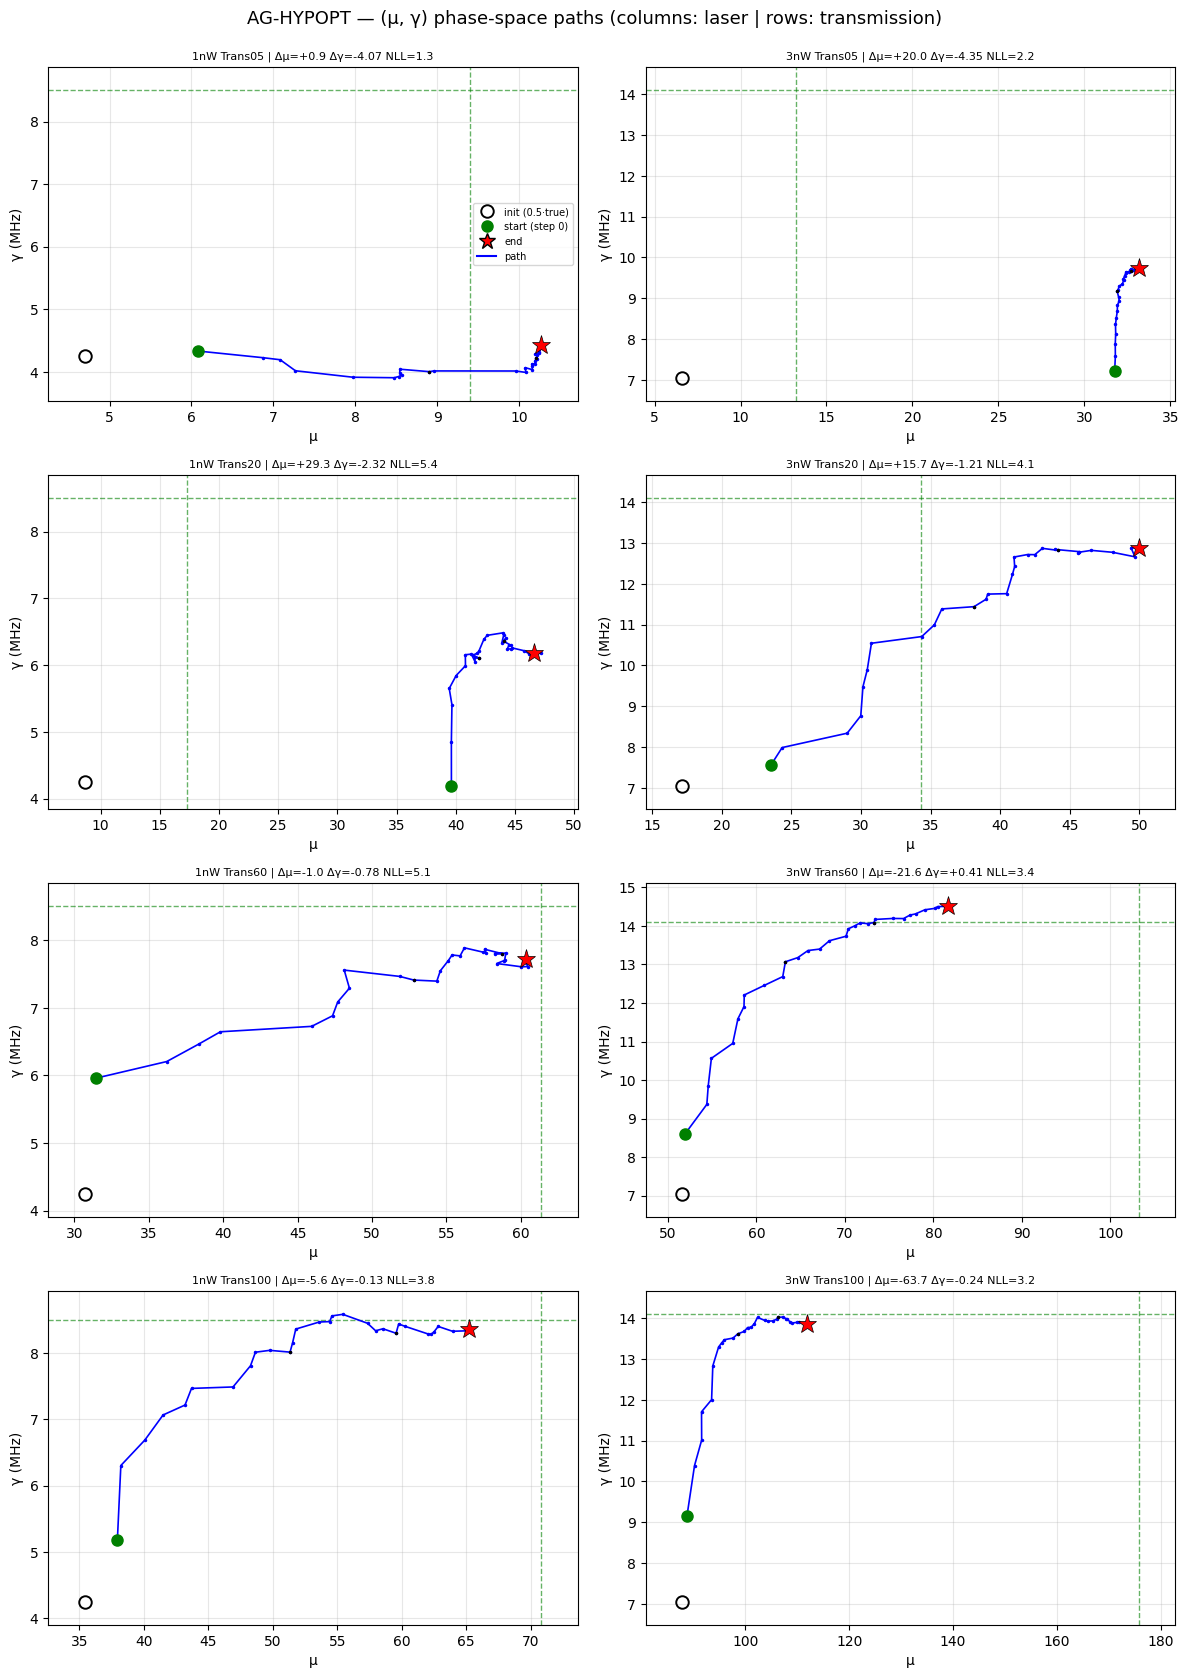

trial finished in 8.3 min
objective = 0.1126 ± 0.0825
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   10.27    +9.3 |     8.50    4.43   -47.9
1nW Trans20       17.32   46.62  +169.3 |     8.50    6.18   -27.3
1nW Trans60       61.37   60.38    -1.6 |     8.50    7.72    -9.1
1nW Trans100       70.82   65.24    -7.9 |     8.50    8.37    -1.6
3nW Trans05       13.20   33.16  +151.1 |    14.10    9.75   -30.8
3nW Trans20       34.28   49.94   +45.7 |    14.10   12.89    -8.6
3nW Trans60      103.20   81.63   -20.9 |    14.10   14.51    +2.9
3nW Trans100      175.71  111.97   -36.3 |    14.10   13.86    -1.7

weighted objective (T-graded, cap=1.0) = 0.1126 | diverged cells: 0
μ: RMSE 27.529 (rel 83.3%, bias -3.260) | γ: RMSE 2.323 (rel 22.8%, bias -1.586)


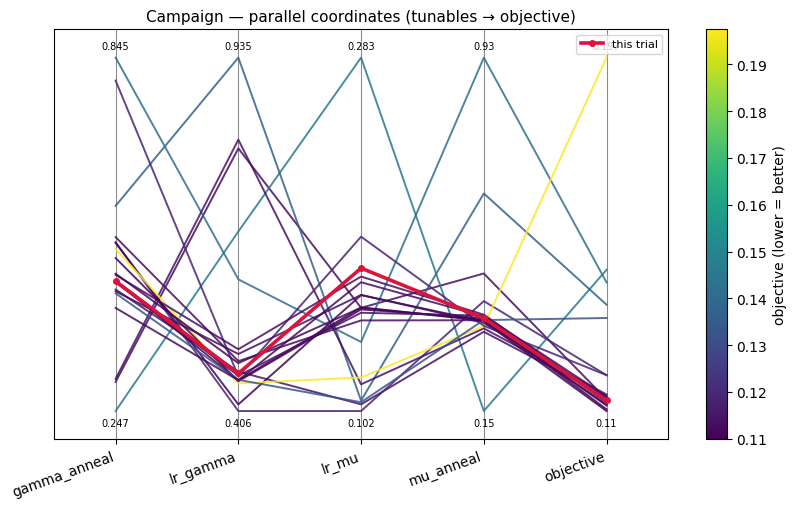

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 20 ran the highest-EI candidate (candidate 3, ei=3.89): `lr_mu=0.1754`, `mu_anneal=0.3548` (effective mu travel 0.144), `lr_gamma=0.4620`, `gamma_anneal=0.4671`. It completed in 8.3 min with objective **0.1126 +/- 0.0825** and **0 diverged cells** — matching trial_09. Ranking: trial_08 0.1099 < trial_15 0.1103 < trial_16 0.1112 < trial_12 0.1115 < trial_18 0.1121 < trial_09 = **trial_20 0.1126** < trial_01 = trial_14 0.1127 < trial_13 0.1132 < trial_05 = trial_19 0.1135 < ...

Aggregate accuracy: **mu rel-RMSE 83.3%** (RMSE 27.53, bias -3.26); **gamma rel-RMSE 22.8%** (RMSE 2.32, bias -1.59).

Per-cell relative errors:
- **mu:** 1nW T05 +9.3%, T20 +169.3%, T60 -1.6%, T100 -7.9% | 3nW T05 +151.1%, T20 +45.7%, T60 -20.9%, T100 -36.3%.
- **gamma:** 1nW T05 -47.9%, T20 -27.3%, T60 -9.1%, T100 -1.6% | 3nW T05 -30.8%, T20 -8.6%, T60 +2.9%, T100 -1.7%.

Another maximum-ei sample on the optimum (travel 0.144), again divergence-free, landed at 0.1126 — the same as trial_09 and inside the plateau. Its 1nW high-T mu was fine (T60 -1.6%, T100 -7.9%) but the mid-T overshoots stayed large (1nW T20 +169.3%, 3nW T05 +151.1%), which is what keeps mu rel-RMSE at 83.3%. With fifteen divergence-free runs now spanning 0.1099-0.1135 in this band and no knob change moving the needle, the plateau is definitive and trial_08's 0.1099 remains the best.

**Summary:** Trial 20 (lr_mu=0.1754, mu_anneal=0.3548, lr_gamma=0.4620, gamma_anneal=0.4671): objective 0.1126 +/- 0.0825 with 0 diverged cells; an optimum sample (travel 0.144) matched trial_09 exactly, so the plateau holds and trial_08 (0.1099) stays best.
**Key insight:** The optimum region keeps returning 0.1099-0.1135 for any near-optimal schedule; with fifteen divergence-free samples the plateau is definitive and trial_08 remains the best of the campaign.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** The hyperparameter search has converged (fifteen divergence-free samples, best nine within ~0.004). Any further gain requires structural changes (per-experiment/n_target-adaptive steps for the mid-T overshoot and low-T gamma; a divergence safeguard) - outside this campaign's scope. Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 20 (lr_mu=0.1754, mu_anneal=0.3548, lr_gamma=0.4620, gamma_anneal=0.4671): objective 0.1126 +/- 0.0825 with 0 diverged cells; an optimum sample (travel 0.144) matched trial_09 exactly, so the plateau holds and trial_08 (0.1099) stays best"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The optimum region keeps returning 0.1099-0.1135 for any near-optimal schedule; with fifteen divergence-free samples the plateau is definitive and trial_08 remains the best of the campaign"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_20 | current best: trial_08


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_21.ipynb. Open it and follow its cells from the top.
